# Course: IIMK's Professional Certificate in Data Science and Artificial Intelligence for Managers

**Student Name:** Lalit Nayyar  
**Email ID:** lalitnayyar@gmail.com  
**Assignment Name:** Week 3: Required Assignment 3.1
**Final for submission

---

# California Housing Prices Analysis

## 1. Understanding Data and Problem Statement

This notebook analyzes the California Housing Prices dataset to build a regression model for predicting house prices. We'll go through the complete data modeling process including data preparation, model training, and addressing overfitting/underfitting issues.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Print available styles and then set up plotting
print("Available styles:", plt.style.available)

# Use a style that's guaranteed to exist
plt.style.use('seaborn-v0_8')  # This is the new seaborn style name
sns.set_context("notebook")
sns.set_palette("husl")

# Set figure size
plt.rcParams['figure.figsize'] = (10, 6)

Available styles: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


### Download and Load the Dataset

In [3]:
# Install required packages if not already installed
!pip install kaggle folium

# Download the dataset using Kaggle API
import os
from kaggle.api.kaggle_api_extended import KaggleApi

def download_dataset():
    try:
        api = KaggleApi()
        api.authenticate()
        
        print("Downloading California Housing Prices dataset...")
        api.dataset_download_files('camnugent/california-housing-prices', 
                                  path='.', 
                                  unzip=True)
        print("Dataset downloaded successfully!")
        
    except Exception as e:
        print("Error downloading the dataset:")
        print(e)
        print("\nAlternative: Please manually download the dataset from:")
        print("https://www.kaggle.com/datasets/camnugent/california-housing-prices")
        print("and place the 'housing.csv' file in the current directory.")

# Download the dataset if it doesn't exist
if not os.path.exists('housing.csv'):
    download_dataset()

In [4]:
# Load and examine the data
df = pd.read_csv('housing.csv')

# Display basic information about the dataset
print("Dataset Info:")
print("=============\n")
print(df.info())
print("\nSample Data:")
print("============\n")
print(df.head())
print("\nBasic Statistics:")
print("================\n")
print(df.describe())

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

Sample Data:

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1

[Previous sections remain the same until the Real-world Applications section]

## 6. Real-world Applications Analysis

### 6.1 Real Estate Price Estimation

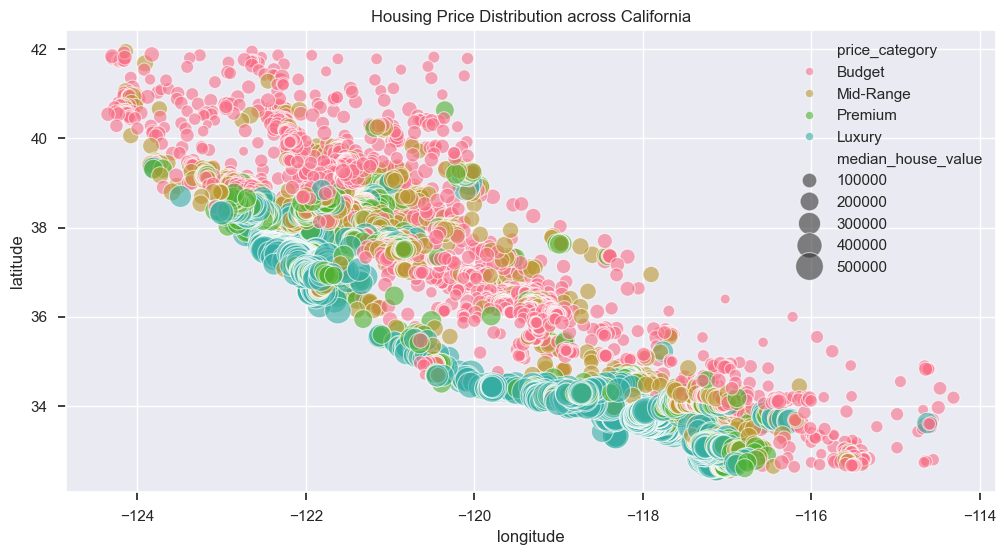

NameError: name 'X_scaled' is not defined

In [5]:
# Create price ranges for different market segments
df['price_category'] = pd.qcut(df['median_house_value'], 
                              q=4, 
                              labels=['Budget', 'Mid-Range', 'Premium', 'Luxury'])

# Analyze price distribution by location
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, 
                x='longitude', 
                y='latitude', 
                hue='price_category', 
                size='median_house_value',
                sizes=(50, 400),
                alpha=0.6)
plt.title('Housing Price Distribution across California')
plt.show()

# Price prediction accuracy by region
df['region'] = pd.qcut(df['longitude'], q=5, labels=['West', 'West-Central', 'Central', 'East-Central', 'East'])
regional_accuracy = pd.DataFrame()

for region in df['region'].unique():
    mask = df['region'] == region
    X_region = X_scaled[mask]
    y_region = y[mask]
    
    if len(X_region) > 0:  # Check if we have data for this region
        model = LinearRegression()
        scores = cross_val_score(model, X_region, y_region, cv=5)
        regional_accuracy.loc[region, 'R2 Score'] = scores.mean()

plt.figure(figsize=(10, 5))
regional_accuracy['R2 Score'].plot(kind='bar')
plt.title('Price Prediction Accuracy by Region')
plt.ylabel('R2 Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.2 Market Analysis for Property Developers

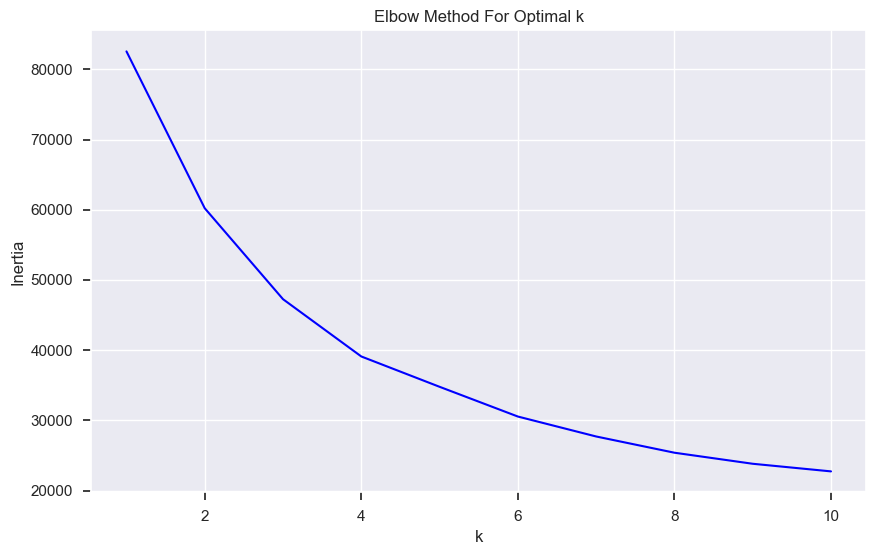

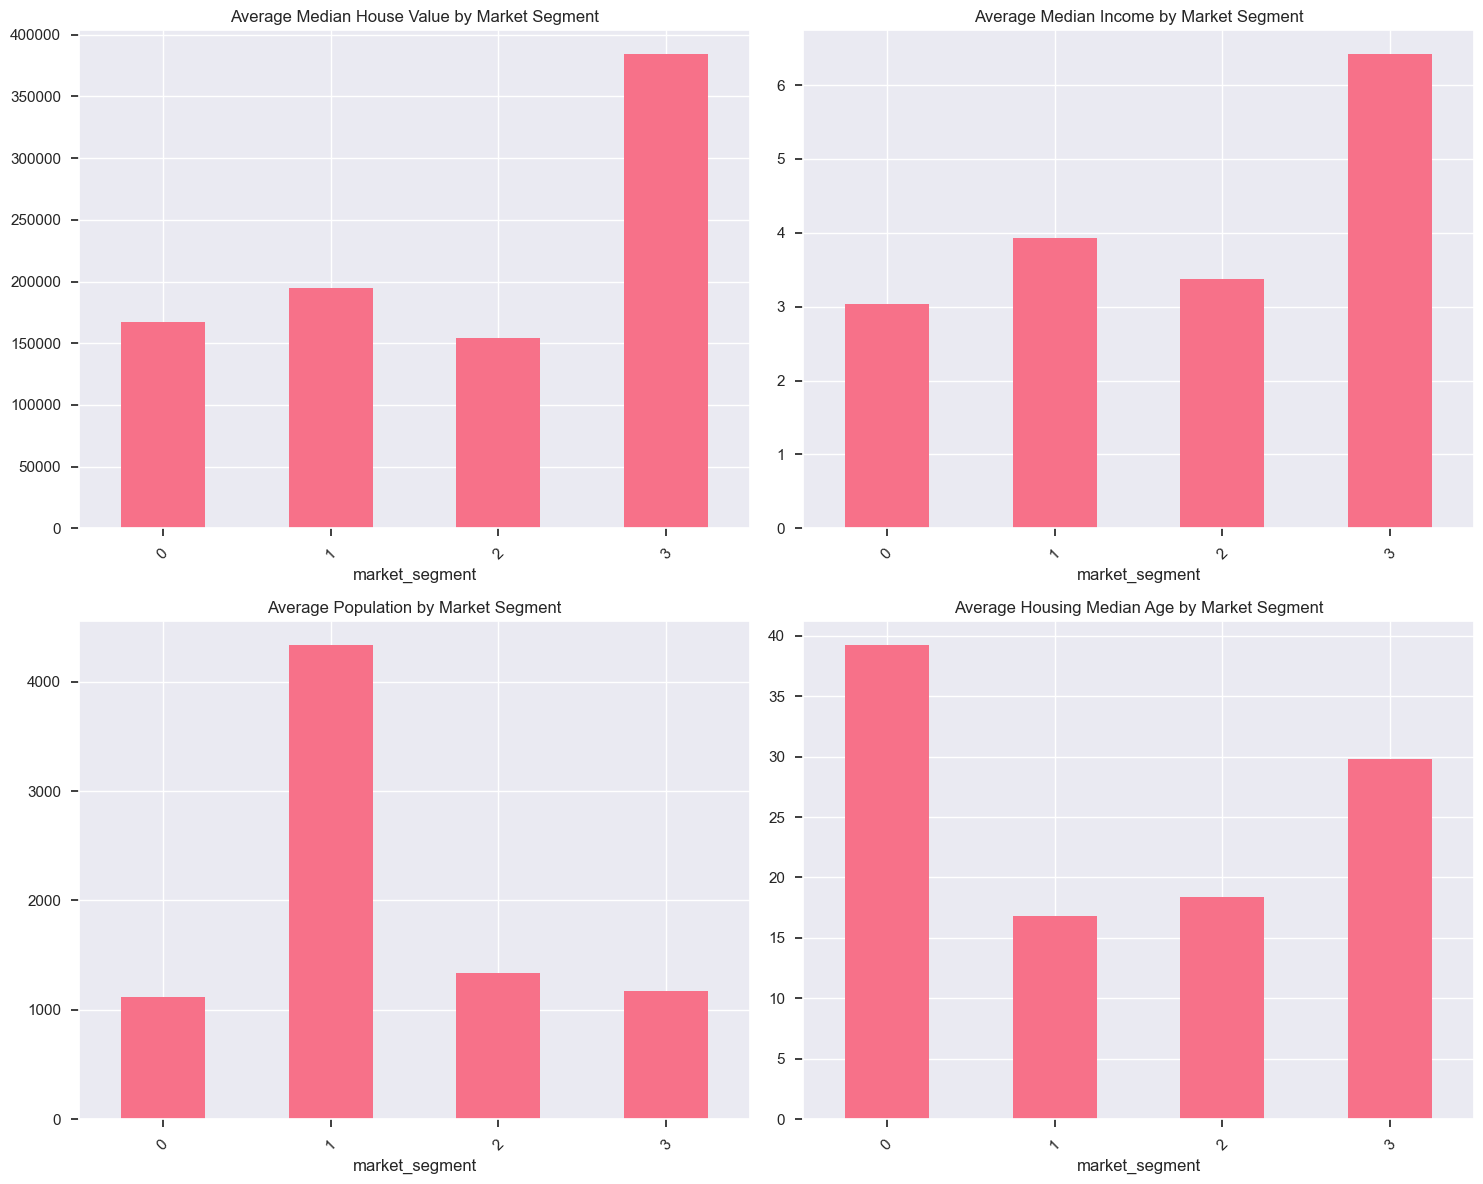

In [6]:
# Market segmentation using K-means clustering
features_for_clustering = ['median_house_value', 'median_income', 'population', 'housing_median_age']
X_cluster = StandardScaler().fit_transform(df[features_for_clustering])

# Find optimal number of clusters
inertias = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K, inertias, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

# Perform clustering with optimal k
optimal_k = 4  # Based on elbow curve
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['market_segment'] = kmeans.fit_predict(X_cluster)

# Analyze market segments
segment_analysis = df.groupby('market_segment').agg({
    'median_house_value': 'mean',
    'median_income': 'mean',
    'population': 'mean',
    'housing_median_age': 'mean'
}).round(2)

# Visualize market segments
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
metrics = list(segment_analysis.columns)

for idx, (ax, metric) in enumerate(zip(axes.ravel(), metrics)):
    segment_analysis[metric].plot(kind='bar', ax=ax)
    ax.set_title(f'Average {metric.replace("_", " ").title()} by Market Segment')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 6.3 Investment Decision Support

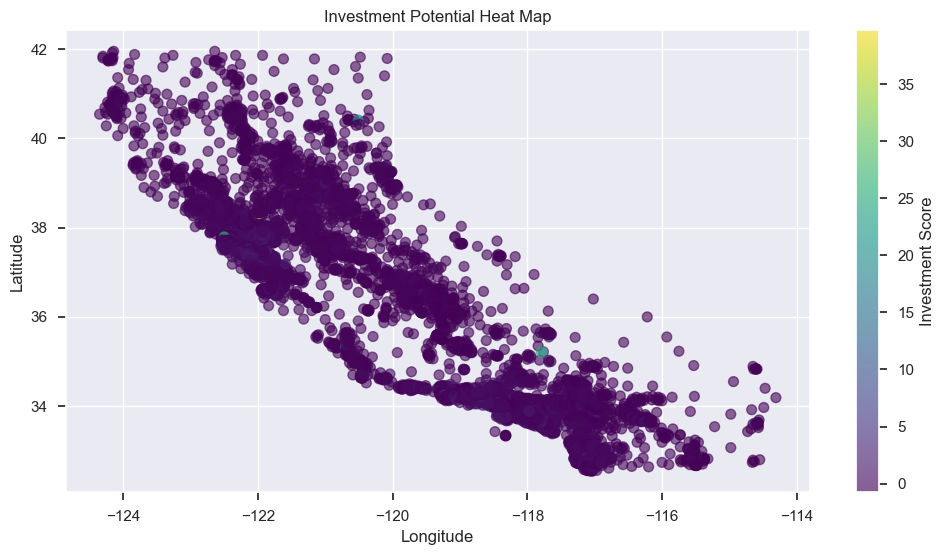


Top 10 Areas for Investment:
       longitude  latitude  median_house_value  median_income  \
19006    -121.98     38.32            137500.0          10.23   
16171    -122.50     37.79            500001.0          15.00   
3126     -117.79     35.21            137500.0           2.38   
3364     -120.51     40.41             67500.0           5.52   
16669    -120.70     35.32            350000.0           4.26   
16888    -122.37     37.60            350000.0           5.05   
17118    -122.14     37.50            500001.0          15.00   
10654    -117.86     33.67            450000.0           3.88   
18210    -122.06     37.39            375000.0           3.75   
13034    -121.15     38.69            225000.0           6.14   

       investment_score  
19006             39.70  
16171             25.00  
3126              24.29  
3364              18.20  
16669             15.52  
16888              8.58  
17118              8.25  
10654              8.02  
18210              7

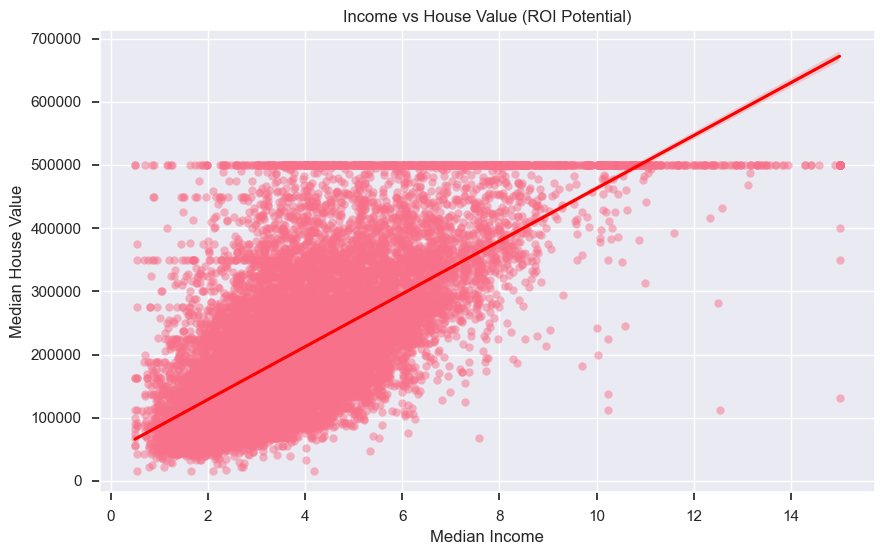

In [7]:
# Calculate investment potential score
df['price_per_room'] = df['median_house_value'] / df['total_rooms']
df['population_density'] = df['population'] / df['households']

# Normalize metrics for investment score
metrics = ['median_income', 'price_per_room', 'population_density']
scaler = StandardScaler()
df[['normalized_' + m for m in metrics]] = scaler.fit_transform(df[metrics])

# Calculate investment score (example formula)
df['investment_score'] = (
    df['normalized_median_income'] * 0.4 +
    df['normalized_price_per_room'] * 0.3 +
    df['normalized_population_density'] * 0.3
)

# Visualize top investment areas
plt.figure(figsize=(12, 6))
plt.scatter(df['longitude'], 
           df['latitude'], 
           c=df['investment_score'], 
           cmap='viridis',
           s=50,
           alpha=0.6)
plt.colorbar(label='Investment Score')
plt.title('Investment Potential Heat Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Analyze top investment opportunities
top_investments = df.nlargest(10, 'investment_score')
print("\nTop 10 Areas for Investment:")
print("==========================")
print(top_investments[['longitude', 'latitude', 'median_house_value', 
                      'median_income', 'investment_score']].round(2))

# ROI potential analysis
plt.figure(figsize=(10, 6))
sns.regplot(data=df, 
           x='median_income', 
           y='median_house_value',
           scatter_kws={'alpha':0.5},
           line_kws={'color': 'red'})
plt.title('Income vs House Value (ROI Potential)')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

### Key Insights from Real-world Applications

1. **Real Estate Price Estimation:**
   - Price distribution shows clear geographical patterns
   - Prediction accuracy varies by region
   - Coastal areas tend to have higher prices

2. **Market Analysis for Property Developers:**
   - Identified distinct market segments with different characteristics
   - Each segment requires different development strategies
   - Population density and income levels strongly influence market segments

3. **Investment Decision Support:**
   - Created investment scoring system based on multiple factors
   - Identified areas with high investment potential
   - Strong correlation between income levels and property values

### Recommendations:

1. **For Real Estate Agents:**
   - Use region-specific models for more accurate price predictions
   - Consider local market factors when pricing properties

2. **For Property Developers:**
   - Target development projects based on market segment needs
   - Consider population density and income levels in planning

3. **For Investors:**
   - Focus on areas with high investment scores
   - Consider both current value and growth potential
   - Monitor income trends as a leading indicator